# Flight Delay Project  
## COMP4381 – Data Science and Analytics  

**Instructor:** Ahmed Sabbah  

**Raheeq Mousa:** 1220515  
**Aya Abdakareem:** 1220020  
**Zaid Mousa:** 1221833  

---

In [2]:
print("Welcome to the Flight Delay Project")

Welcome to the Flight Delay Project


In [4]:
pip install gdown

Note: you may need to restart the kernel to use updated packages.


<p style="font-weight:bold;font-size:18px">RUN THE CELL BELOW ONLY IF YOU HAD NOT DOWNLOADED THE DATASET BEFORE!</p>

In [7]:
#YOU DON'T NEED TO RUN THIS CELL EVERYTIME, ONLY IF YOU HADN'T DOWNLOADED THE DATASET
import gdown

file_id = "1BBnDY8JWrR-0faAEmZmKaDEHIZE6FreQ"
url = f"https://drive.google.com/uc?id={file_id}"
output = "data/raw/flight_data_2024.csv"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1BBnDY8JWrR-0faAEmZmKaDEHIZE6FreQ
From (redirected): https://drive.google.com/uc?id=1BBnDY8JWrR-0faAEmZmKaDEHIZE6FreQ&confirm=t&uuid=df0a79f3-f6a3-4c07-a223-74d1b4e20fe9
To: C:\Users\victus\OneDrive\Attachments\Desktop\Raheeq\Smstrs\8th_smstr_RaheeqMousa\Data science\Flight-Delay-Prediction\data\raw\flight_data_2024.csv
100%|██████████| 1.31G/1.31G [34:32<00:00, 632kB/s]  


'data/raw/flight_data_2024.csv'

In [8]:
pip install pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import os

c:\Users\victus\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [12]:
df= pd.read_csv('data/raw/flight_data_2024.csv')

C:\Users\victus\AppData\Local\Temp\ipykernel_19728\1977606443.py:1: DtypeWarning: Columns (0: cancellation_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('data/raw/flight_data_2024.csv')


First lets remove the cancelled and diverted flights from the dataframe since they don't have arrival delay<br>
and i can't classifiy them whether they are delayed or not

In [15]:
df = df[df["cancelled"] == 0]
df = df[df["diverted"] == 0]

# Sampling

create a new column weather the flight is delayed or not (0 = not delayed / 1 = delayed)

In [19]:
df['delayed']=(df['arr_delay']>=15).astype(int)

Making Stratified Sampling while keepingg aware of the distribution stay the same

In [22]:
print(f"Before a sampling, ratio of delayed flights {df['delayed'].mean()} and ratio of non delayed {(df['delayed']==0).mean()}")

total=500000
delayed_ratio= df['delayed'].mean()

number_delayed= int(total*delayed_ratio)
number_non_delayed= total-number_delayed

delayed_flights=df[df['delayed']==1].sample(n=number_delayed,random_state=7)
non_delayed_flights=df[df['delayed']==0].sample(n=number_non_delayed,random_state=7)

sampled_flights=pd.concat([delayed_flights,non_delayed_flights]).sample(frac=1, random_state=4)
print(f"After a stratified sampling, ratio of delayed flights {number_delayed/total} and ratio of non delayed {number_non_delayed/total}")

Before a sampling, ratio of delayed flights 0.20817177575532997 and ratio of non delayed 0.79182822424467
After a stratified sampling, ratio of delayed flights 0.20817 and ratio of non delayed 0.79183


Write the sampled data to a new file

In [25]:
os.makedirs('data/sampled', exist_ok=True)

In [27]:
sampled_flights.to_csv('data/sampled/sampled_flights.csv')

# Data Collection and merging the data

In [30]:
df = pd.read_csv('data/sampled/sampled_flights.csv')

In [32]:
df=df[['year','month','day_of_month','day_of_week',
'fl_date','distance',
'origin','origin_city_name','origin_state_nm','dest', 
'dest_city_name','dest_state_nm','op_unique_carrier','op_carrier_fl_num',
'crs_dep_time','crs_arr_time','delayed']]


I fetched the airport data long and lat inorder to get the latitude and longitudde fro the origin and dest airports.

In [35]:
airports = pd.read_csv("data/raw/airports.csv") 
airport_cord = airports[["iata", "lat", "lon"]]

srop the rows that contains na values

In [38]:
airport_cord = airport_cord.dropna()

check the correctness of the lat and lng

In [41]:
airport_cord[
    (airport_cord['lat'] < -90) | (airport_cord['lat'] > 90) |
    (airport_cord['lon'] < -180) | (airport_cord['lon'] > 180)
]

,iata,lat,lon


we renamed the columns name of the airports data (airport -> origin) inorder to match the column name in the dataframe
and made a left join to keep all rows from out dataframe, and only add matching airport info (latitude and longitude) when it exists.

In [44]:
airport_cord.columns = ["origin", "origin_lat", "origin_lng"]
df=pd.merge(df,airport_cord,on='origin', how='left')

we renamed the columns name of the airports data (airport -> dest) inorder to match the column name in the dataframe
and made a left join to keep all rows from out dataframe, and only add matching airport info (latitude and longitude) when it exists.

In [47]:
airport_cord.columns = ["dest", "dest_lat", "dest_lng"]
df=pd.merge(df,airport_cord,on='dest', how='left')

In [49]:
print(df['origin_lat'].isna().any())
print(df['origin_lng'].isna().any())
print(df['dest_lat'].isna().any())
print(df['dest_lng'].isna().any())

False
False
False
False


no missing values in origin_lat<br>
no missing values in origin_lng<br>
no missing values in dest_lat<br>
no missing values in dest_lng<br>
Every origin and dest in our dataframe matched with the airport_cord dataframe

In [52]:
df.head(3)

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,dest_state_nm,op_unique_carrier,op_carrier_fl_num,crs_dep_time,crs_arr_time,delayed,origin_lat,origin_lng,dest_lat,dest_lng
0,2024,6,3,1,2024-06-03,1042.0,IAH,"Houston, TX",Texas,RDU,...,North Carolina,F9,4610.0,813,1158,0,29.984435,-95.341442,35.877639,-78.787472
1,2024,2,22,4,2024-02-22,156.0,DEC,"Decatur, IL",Illinois,ORD,...,Illinois,OO,5037.0,925,1031,0,39.834562,-88.865689,41.976940,-87.908150
2,2024,5,6,1,2024-05-06,672.0,OAK,"Oakland, CA",California,SEA,...,Washington,WN,3500.0,1645,1855,0,37.721261,-122.221151,47.449889,-122.311778


# Preprocessing and Cleaning the data

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   year               500000 non-null  int64  
 1   month              500000 non-null  int64  
 2   day_of_month       500000 non-null  int64  
 3   day_of_week        500000 non-null  int64  
 4   fl_date            500000 non-null  str    
 5   distance           500000 non-null  float64
 6   origin             500000 non-null  str    
 7   origin_city_name   500000 non-null  str    
 8   origin_state_nm    500000 non-null  str    
 9   dest               500000 non-null  str    
 10  dest_city_name     500000 non-null  str    
 11  dest_state_nm      500000 non-null  str    
 12  op_unique_carrier  500000 non-null  str    
 13  op_carrier_fl_num  500000 non-null  float64
 14  crs_dep_time       500000 non-null  int64  
 15  crs_arr_time       500000 non-null  int64  
 16  delayed      

## 1. Validate data types

In [58]:
df['fl_date']

0         2024-06-03
1         2024-02-22
2         2024-05-06
3         2024-02-09
4         2024-03-24
             ...    
499995    2024-07-05
499996    2024-04-27
499997    2024-10-12
499998    2024-05-10
499999    2024-12-31
Name: fl_date, Length: 500000, dtype: str

We converted the fl_date column to datetime type

In [61]:
df['fl_date'] = pd.to_datetime(df['fl_date'])
df

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,dest_state_nm,op_unique_carrier,op_carrier_fl_num,crs_dep_time,crs_arr_time,delayed,origin_lat,origin_lng,dest_lat,dest_lng
0,2024,6,3,1,2024-06-03,1042.0,IAH,"Houston, TX",Texas,RDU,...,North Carolina,F9,4610.0,813,1158,0,29.984435,-95.341442,35.877639,-78.787472
1,2024,2,22,4,2024-02-22,156.0,DEC,"Decatur, IL",Illinois,ORD,...,Illinois,OO,5037.0,925,1031,0,39.834562,-88.865689,41.976940,-87.908150
2,2024,5,6,1,2024-05-06,672.0,OAK,"Oakland, CA",California,SEA,...,Washington,WN,3500.0,1645,1855,0,37.721261,-122.221151,47.449889,-122.311778
3,2024,2,9,5,2024-02-09,1183.0,RSW,"Fort Myers, FL",Florida,MKE,...,Wisconsin,F9,3217.0,839,1101,0,26.536164,-81.755155,42.946932,-87.897064
4,2024,3,24,7,2024-03-24,1163.0,XNA,"Fayetteville, AR",Arkansas,LAS,...,Nevada,G4,89.0,2206,2316,0,36.281579,-94.307766,36.080343,-115.152449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,2024,7,5,5,2024-07-05,1041.0,SAT,"San Antonio, TX",Texas,ORD,...,Illinois,UA,2629.0,700,955,0,29.533958,-98.469057,41.976940,-87.908150
499996,2024,4,27,6,2024-04-27,972.0,MDW,"Chicago, IL",Illinois,AUS,...,Texas,WN,204.0,1320,1555,0,41.785643,-87.752729,30.194527,-97.669876
499997,2024,10,12,6,2024-10-12,372.0,SFO,"San Francisco, CA",California,SNA,...,California,OO,3494.0,1035,1209,0,37.618806,-122.375417,33.675662,-117.868233
499998,2024,5,10,5,2024-05-10,1371.0,STL,"St. Louis, MO",Missouri,LAS,...,Nevada,WN,2012.0,1405,1540,0,38.748698,-90.370026,36.080343,-115.152449


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   year               500000 non-null  int64         
 1   month              500000 non-null  int64         
 2   day_of_month       500000 non-null  int64         
 3   day_of_week        500000 non-null  int64         
 4   fl_date            500000 non-null  datetime64[us]
 5   distance           500000 non-null  float64       
 6   origin             500000 non-null  str           
 7   origin_city_name   500000 non-null  str           
 8   origin_state_nm    500000 non-null  str           
 9   dest               500000 non-null  str           
 10  dest_city_name     500000 non-null  str           
 11  dest_state_nm      500000 non-null  str           
 12  op_unique_carrier  500000 non-null  str           
 13  op_carrier_fl_num  500000 non-null  float64       
 14 

There is no meaning of the op_carrier_fl_num to be a float data, it is just a string id

In [66]:
df['op_carrier_fl_num'].isna().sum()

np.int64(0)

check the datatype of the feature

In [69]:
df['op_carrier_fl_num'].dtype

dtype('float64')

since the values were stored as floats,<br> we verified whether they contained any decimal parts by checking if the remainder after division by 1 was zero.

In [72]:
df['op_carrier_fl_num'].apply(lambda x: x % 1 != 0).sum()

np.int64(0)

since we found the remainder of all values is zero.<br> Therefore, all of op_carrier_fl_num can be converted from float to integer format successfully,

In [75]:
df['op_carrier_fl_num']=df['op_carrier_fl_num'].astype(int)

now the op_carrier_fl_num feature is converted finally to string format.

In [78]:
df['op_carrier_fl_num']=df['op_carrier_fl_num'].astype(str)
df

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,dest_state_nm,op_unique_carrier,op_carrier_fl_num,crs_dep_time,crs_arr_time,delayed,origin_lat,origin_lng,dest_lat,dest_lng
0,2024,6,3,1,2024-06-03,1042.0,IAH,"Houston, TX",Texas,RDU,...,North Carolina,F9,4610,813,1158,0,29.984435,-95.341442,35.877639,-78.787472
1,2024,2,22,4,2024-02-22,156.0,DEC,"Decatur, IL",Illinois,ORD,...,Illinois,OO,5037,925,1031,0,39.834562,-88.865689,41.976940,-87.908150
2,2024,5,6,1,2024-05-06,672.0,OAK,"Oakland, CA",California,SEA,...,Washington,WN,3500,1645,1855,0,37.721261,-122.221151,47.449889,-122.311778
3,2024,2,9,5,2024-02-09,1183.0,RSW,"Fort Myers, FL",Florida,MKE,...,Wisconsin,F9,3217,839,1101,0,26.536164,-81.755155,42.946932,-87.897064
4,2024,3,24,7,2024-03-24,1163.0,XNA,"Fayetteville, AR",Arkansas,LAS,...,Nevada,G4,89,2206,2316,0,36.281579,-94.307766,36.080343,-115.152449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,2024,7,5,5,2024-07-05,1041.0,SAT,"San Antonio, TX",Texas,ORD,...,Illinois,UA,2629,700,955,0,29.533958,-98.469057,41.976940,-87.908150
499996,2024,4,27,6,2024-04-27,972.0,MDW,"Chicago, IL",Illinois,AUS,...,Texas,WN,204,1320,1555,0,41.785643,-87.752729,30.194527,-97.669876
499997,2024,10,12,6,2024-10-12,372.0,SFO,"San Francisco, CA",California,SNA,...,California,OO,3494,1035,1209,0,37.618806,-122.375417,33.675662,-117.868233
499998,2024,5,10,5,2024-05-10,1371.0,STL,"St. Louis, MO",Missouri,LAS,...,Nevada,WN,2012,1405,1540,0,38.748698,-90.370026,36.080343,-115.152449


In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   year               500000 non-null  int64         
 1   month              500000 non-null  int64         
 2   day_of_month       500000 non-null  int64         
 3   day_of_week        500000 non-null  int64         
 4   fl_date            500000 non-null  datetime64[us]
 5   distance           500000 non-null  float64       
 6   origin             500000 non-null  str           
 7   origin_city_name   500000 non-null  str           
 8   origin_state_nm    500000 non-null  str           
 9   dest               500000 non-null  str           
 10  dest_city_name     500000 non-null  str           
 11  dest_state_nm      500000 non-null  str           
 12  op_unique_carrier  500000 non-null  str           
 13  op_carrier_fl_num  500000 non-null  str           
 14 

## 2. Solving Inconsistency

Here we are checking the string columns, if they have an entry containins additional space (not trimmed string)

In [84]:
str_cols = ['origin', 'origin_city_name', 'origin_state_nm',
            'dest', 'dest_city_name', 'dest_state_nm',
            'op_unique_carrier', 'op_carrier_fl_num']

for c in str_cols:
    raw   = df[c].nunique()
    non_trimmed_strings = df[c].str.strip().str.upper().nunique()
    if raw == non_trimmed_strings:
        print(f"no issues at {c} ({raw} unique values)")
    else:
        print(f"{c}: {raw - non_trimmed_strings} values are not trimmed")

no issues at origin (347 unique values)
no issues at origin_city_name (341 unique values)
no issues at origin_state_nm (52 unique values)
no issues at dest (347 unique values)
no issues at dest_city_name (341 unique values)
no issues at dest_state_nm (52 unique values)
no issues at op_unique_carrier (15 unique values)
no issues at op_carrier_fl_num (6664 unique values)


Here we are checking the string columns, if they have an entry is repeated with other cases (such as: BNA -> bna, Bna)

In [86]:
str_cols = ['origin', 'origin_city_name', 'origin_state_nm',
            'dest', 'dest_city_name', 'dest_state_nm',
            'op_unique_carrier', 'op_carrier_fl_num']
for c in str_cols:
    raw   = df[c].nunique()
    capital_strings = df[c].str.upper().nunique() #this convert the string to capital then counts unique values
    if raw == capital_strings:
        print(f"No case problems at {c}, and ({raw} unique values)")
    else:
        print(f"There is a case problem at {c}, and ({raw-capital_strings} have problems)")

No case problems at origin, and (347 unique values)
No case problems at origin_city_name, and (341 unique values)
No case problems at origin_state_nm, and (52 unique values)
No case problems at dest, and (347 unique values)
No case problems at dest_city_name, and (341 unique values)
No case problems at dest_state_nm, and (52 unique values)
No case problems at op_unique_carrier, and (15 unique values)
No case problems at op_carrier_fl_num, and (6664 unique values)


In [88]:
(df["day_of_month"] != df["fl_date"].dt.day).any()

np.False_

In [91]:
df[df["day_of_week"] != df["fl_date"].dt.dayofweek]["day_of_week"].value_counts()

day_of_week
1    75692
5    74567
7    74147
4    73618
2    68730
3    68655
6    64591
Name: count, dtype: int64

In [93]:
(df["day_of_week"]-1 != df["fl_date"].dt.dayofweek).any()

np.False_

I wrote df["day_of_week"]-1 because the day_of_week in this dataset is encoded 1-7 instead of 0-6<br>
I checked the consistency of the days of the week after adjusting them according to indexing differences. 

In [96]:
(df["month"] != df["fl_date"].dt.month).any()

np.False_

In [98]:
(df["year"] != df["fl_date"].dt.year).any()

np.False_

In [100]:
#check if there is zero ot negative distances
df[df['distance']<=0]

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,dest_state_nm,op_unique_carrier,op_carrier_fl_num,crs_dep_time,crs_arr_time,delayed,origin_lat,origin_lng,dest_lat,dest_lng


Here we check if there is an unusual arrival and departure time

In [103]:
df[(df['crs_dep_time'] > 2359) | (df['crs_dep_time'] < 0)]
df[(df['crs_arr_time'] > 2359) | (df['crs_arr_time'] < 0)]

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,dest_state_nm,op_unique_carrier,op_carrier_fl_num,crs_dep_time,crs_arr_time,delayed,origin_lat,origin_lng,dest_lat,dest_lng


There are no unsual scheduled departure and arrival time

## 3. Duplicates

In [107]:
df[df.duplicated()]

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,dest_state_nm,op_unique_carrier,op_carrier_fl_num,crs_dep_time,crs_arr_time,delayed,origin_lat,origin_lng,dest_lat,dest_lng


No duplicates appeared in the dataframe

## 4. Missing data

In [111]:
df.isna().sum()

year                 0
month                0
day_of_month         0
day_of_week          0
fl_date              0
distance             0
origin               0
origin_city_name     0
origin_state_nm      0
dest                 0
dest_city_name       0
dest_state_nm        0
op_unique_carrier    0
op_carrier_fl_num    0
crs_dep_time         0
crs_arr_time         0
delayed              0
origin_lat           0
origin_lng           0
dest_lat             0
dest_lng             0
dtype: int64

As you see there are no Missing data in the dataframe

## 5. Outliers

Here we created a column called distance_zscore where we measured how many standard deviation each value is from the mean in standard deviations.<br> 
Then we created a column called distance_outlier that marks values as outlier if greater or equal to 3.<br>
As shown, the result display the number of outlier and non-outlier observaions in the dataset.

In [116]:
df['distance_zscore']= (df['distance']-df['distance'].mean())/df['distance'].std()
df['distance_outlier'] = df['distance_zscore'].apply(lambda x: abs(x) >= 3)
df["distance_outlier"].value_counts()

distance_outlier
False    495699
True       4301
Name: count, dtype: int64

In [118]:
(df["distance_outlier"]==True).sum()/len(df["distance_outlier"])

np.float64(0.008602)

Only 0.86% of flights are distance outliers, that means the data is consistent.<br>
there exists some extremly short routes<br>
and exists some extremly long routes<br>

# Add features

Add a season column for the flights<br>
it assigns a season label to each flight based on its month.

In [123]:
seasons = []

for m in df['month']:
    if m <= 2:
        seasons.append('winter')
    elif m <= 5:
        seasons.append('spring')
    elif m <= 8:
        seasons.append('summer')
    else:
        seasons.append('fall')

df['season'] = seasons

We introduced a new feature called “is_weekend” <br>which assigns a binary value to each flight indicating whether it occurs in weekend or not (0=not weekend, 1=weekend). 

In [126]:
df['is_weekend'] = df['day_of_week'] >= 6

The feature type of "is_weekend" now is bool and we want to encode it into 0/1 (0=not weekend, 1=weekend).

In [129]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   year               500000 non-null  int64         
 1   month              500000 non-null  int64         
 2   day_of_month       500000 non-null  int64         
 3   day_of_week        500000 non-null  int64         
 4   fl_date            500000 non-null  datetime64[us]
 5   distance           500000 non-null  float64       
 6   origin             500000 non-null  str           
 7   origin_city_name   500000 non-null  str           
 8   origin_state_nm    500000 non-null  str           
 9   dest               500000 non-null  str           
 10  dest_city_name     500000 non-null  str           
 11  dest_state_nm      500000 non-null  str           
 12  op_unique_carrier  500000 non-null  str           
 13  op_carrier_fl_num  500000 non-null  str           
 14 

We converted the type of Here we converted the is_weekend feature into and integer type

In [132]:
df['is_weekend'] = df['is_weekend'].astype(int)

As you see is_weekend feature became an integer type. 

In [135]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   year               500000 non-null  int64         
 1   month              500000 non-null  int64         
 2   day_of_month       500000 non-null  int64         
 3   day_of_week        500000 non-null  int64         
 4   fl_date            500000 non-null  datetime64[us]
 5   distance           500000 non-null  float64       
 6   origin             500000 non-null  str           
 7   origin_city_name   500000 non-null  str           
 8   origin_state_nm    500000 non-null  str           
 9   dest               500000 non-null  str           
 10  dest_city_name     500000 non-null  str           
 11  dest_state_nm      500000 non-null  str           
 12  op_unique_carrier  500000 non-null  str           
 13  op_carrier_fl_num  500000 non-null  str           
 14 

We converted the type of distance_outlier from boolean to integer (1=is distance outlier, 0= not a distance outlier). 

In [138]:
df['distance_outlier'] = df['distance_outlier'].astype(int)

As shown below, the datatype of distance_outlier now is an integer. 

In [141]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   year               500000 non-null  int64         
 1   month              500000 non-null  int64         
 2   day_of_month       500000 non-null  int64         
 3   day_of_week        500000 non-null  int64         
 4   fl_date            500000 non-null  datetime64[us]
 5   distance           500000 non-null  float64       
 6   origin             500000 non-null  str           
 7   origin_city_name   500000 non-null  str           
 8   origin_state_nm    500000 non-null  str           
 9   dest               500000 non-null  str           
 10  dest_city_name     500000 non-null  str           
 11  dest_state_nm      500000 non-null  str           
 12  op_unique_carrier  500000 non-null  str           
 13  op_carrier_fl_num  500000 non-null  str           
 14 

We first extracted the departure hour from the scheduled departure time (crs_dep_time).<br>
Then, we created a new feature called period_of_day, which categorizes each flight as morning, afternoon, evening, or night based on its departure hour.

In [144]:
df['departure_hour'] = df['crs_dep_time'] // 100

In [146]:
result = []

for h in df['departure_hour']:
    if 5 <= h <= 11:
        result.append('morning')
    elif 12 <= h <= 16:
        result.append('afternoon')
    elif 17 <= h <= 20:
        result.append('evening')
    else:
        result.append('night')

df['period_of_day'] = result

As you see in the image below, the periodofday feature is added successfully. 

In [149]:
df.head(3)

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,origin_lat,origin_lng,dest_lat,dest_lng,distance_zscore,distance_outlier,season,is_weekend,departure_hour,period_of_day
0,2024,6,3,1,2024-06-03,1042.0,IAH,"Houston, TX",Texas,RDU,...,29.984435,-95.341442,35.877639,-78.787472,0.349455,0,summer,0,8,morning
1,2024,2,22,4,2024-02-22,156.0,DEC,"Decatur, IL",Illinois,ORD,...,39.834562,-88.865689,41.976940,-87.908150,-1.135956,0,winter,0,9,morning
2,2024,5,6,1,2024-05-06,672.0,OAK,"Oakland, CA",California,SEA,...,37.721261,-122.221151,47.449889,-122.311778,-0.270863,0,spring,0,16,afternoon


In [151]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   year               500000 non-null  int64         
 1   month              500000 non-null  int64         
 2   day_of_month       500000 non-null  int64         
 3   day_of_week        500000 non-null  int64         
 4   fl_date            500000 non-null  datetime64[us]
 5   distance           500000 non-null  float64       
 6   origin             500000 non-null  str           
 7   origin_city_name   500000 non-null  str           
 8   origin_state_nm    500000 non-null  str           
 9   dest               500000 non-null  str           
 10  dest_city_name     500000 non-null  str           
 11  dest_state_nm      500000 non-null  str           
 12  op_unique_carrier  500000 non-null  str           
 13  op_carrier_fl_num  500000 non-null  str           
 14 

In [153]:
df.to_csv('data/processed/processed_flights.csv')

### Load Dataset after Cleaing 

### Read the dataset 

In [4]:
dataset = pd.read_csv('data/processed/processed_flights.csv')

### Review Dataset 

for this part we try to review the dataset after cleaning to make sure that there are no null value and we use .info() , isna() , head , tail 

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 28 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         500000 non-null  int64  
 1   year               500000 non-null  int64  
 2   month              500000 non-null  int64  
 3   day_of_month       500000 non-null  int64  
 4   day_of_week        500000 non-null  int64  
 5   fl_date            500000 non-null  str    
 6   distance           500000 non-null  float64
 7   origin             500000 non-null  str    
 8   origin_city_name   500000 non-null  str    
 9   origin_state_nm    500000 non-null  str    
 10  dest               500000 non-null  str    
 11  dest_city_name     500000 non-null  str    
 12  dest_state_nm      500000 non-null  str    
 13  op_unique_carrier  500000 non-null  str    
 14  op_carrier_fl_num  500000 non-null  int64  
 15  crs_dep_time       500000 non-null  int64  
 16  crs_arr_time 

In [6]:
dataset.head()

,Unnamed: 0,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,...,origin_lat,origin_lng,dest_lat,dest_lng,distance_zscore,distance_outlier,season,is_weekend,departure_hour,period_of_day
0,0,2024,6,3,1,2024-06-03,1042.0,IAH,"Houston, TX",Texas,...,29.984435,-95.341442,35.877639,-78.787472,0.349455,0,summer,0,8,morning
1,1,2024,2,22,4,2024-02-22,156.0,DEC,"Decatur, IL",Illinois,...,39.834562,-88.865689,41.976940,-87.908150,-1.135956,0,winter,0,9,morning
2,2,2024,5,6,1,2024-05-06,672.0,OAK,"Oakland, CA",California,...,37.721261,-122.221151,47.449889,-122.311778,-0.270863,0,spring,0,16,afternoon
3,3,2024,2,9,5,2024-02-09,1183.0,RSW,"Fort Myers, FL",Florida,...,26.536164,-81.755155,42.946932,-87.897064,0.585847,0,winter,0,8,morning
4,4,2024,3,24,7,2024-03-24,1163.0,XNA,"Fayetteville, AR",Arkansas,...,36.281579,-94.307766,36.080343,-115.152449,0.552316,0,spring,1,22,night


In [7]:
dataset.tail()

,Unnamed: 0,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,...,origin_lat,origin_lng,dest_lat,dest_lng,distance_zscore,distance_outlier,season,is_weekend,departure_hour,period_of_day
499995,499995,2024,7,5,5,2024-07-05,1041.0,SAT,"San Antonio, TX",Texas,...,29.533958,-98.469057,41.976940,-87.908150,0.347779,0,summer,0,7,morning
499996,499996,2024,4,27,6,2024-04-27,972.0,MDW,"Chicago, IL",Illinois,...,41.785643,-87.752729,30.194527,-97.669876,0.232098,0,spring,1,13,afternoon
499997,499997,2024,10,12,6,2024-10-12,372.0,SFO,"San Francisco, CA",California,...,37.618806,-122.375417,33.675662,-117.868233,-0.773824,0,fall,1,10,morning
499998,499998,2024,5,10,5,2024-05-10,1371.0,STL,"St. Louis, MO",Missouri,...,38.748698,-90.370026,36.080343,-115.152449,0.901035,0,spring,0,14,afternoon
499999,499999,2024,12,31,2,2024-12-31,1042.0,GRR,"Grand Rapids, MI",Michigan,...,42.880833,-85.522806,29.984435,-95.341442,0.349455,0,fall,0,6,morning


In [8]:
dataset.columns

Index(['Unnamed: 0', 'year', 'month', 'day_of_month', 'day_of_week', 'fl_date',
       'distance', 'origin', 'origin_city_name', 'origin_state_nm', 'dest',
       'dest_city_name', 'dest_state_nm', 'op_unique_carrier',
       'op_carrier_fl_num', 'crs_dep_time', 'crs_arr_time', 'delayed',
       'origin_lat', 'origin_lng', 'dest_lat', 'dest_lng', 'distance_zscore',
       'distance_outlier', 'season', 'is_weekend', 'departure_hour',
       'period_of_day'],
      dtype='str')

In [9]:
dataset.isna().sum()

Unnamed: 0           0
year                 0
month                0
day_of_month         0
day_of_week          0
fl_date              0
distance             0
origin               0
origin_city_name     0
origin_state_nm      0
dest                 0
dest_city_name       0
dest_state_nm        0
op_unique_carrier    0
op_carrier_fl_num    0
crs_dep_time         0
crs_arr_time         0
delayed              0
origin_lat           0
origin_lng           0
dest_lat             0
dest_lng             0
distance_zscore      0
distance_outlier     0
season               0
is_weekend           0
departure_hour       0
period_of_day        0
dtype: int64

### Drop unnamed column 

In [10]:
dataset = dataset.drop(columns=['Unnamed: 0'])

### Review the count for delayed and not delayed flights 

we can see that delayed flight it's about 20% of the dataset and not delayed flights it's about 70% of the dataset 

In [11]:
dataset['delayed'].value_counts()

delayed
0    395915
1    104085
Name: count, dtype: int64

### Print the number of origin cities

In [13]:
origin_cities_count = dataset['origin_city_name'].nunique()
print("Number of origin cities:", origin_cities_count)

Number of origin cities: 341


### Print the number of destination cities

In [14]:
dest_cities_count= dataset['dest_city_name'].nunique()
print("number of destination cities", dest_cities_count)

number of destination cities 341


### Summarization , interpretation 

### Interpretation of Mode 
The mode represents the most frequently occurring value in each column  

- We can see that the largest number of flight trips in 2024 occurred during the morning period of the day, in July (month 7), and on the 15th day of the month. the reasen may is that morning flights benefit from clearer air and more stable weather conditions compared to other times of the day. July also has a high number of flights because it is part of the summer vacation season, when many people travel.
- We can also say that October 17th is the date with the highest number of flights.
- A distance of 337 is the most common flight distance in the dataset.
- Fall is the season with the highest number of flight trips. In addition, most flights do not occur on weekends, and the majority of flights have a duration of approximately 7 h.

In [15]:
dataset.mode()

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,origin_lat,origin_lng,dest_lat,dest_lng,distance_zscore,distance_outlier,season,is_weekend,departure_hour,period_of_day
0,2024,7,15,1,2024-10-17,337.0,ATL,"Chicago, IL",Texas,ATL,...,33.6367,-84.427864,33.6367,-84.427864,-0.832503,0,fall,0,7,morning


### Categorical Data Analysis

### Check which season is the most season that may have delayed 
in this cell we try to cheack which season have the most delayed 

we find that summer is the season that have the most delayed may that happen because people late at the flight , then we have spring , fall , winter 

In [16]:
dataset[dataset['delayed'] == 1]["season"].value_counts()

season
summer    34219
spring    28169
fall      26777
winter    14920
Name: count, dtype: int64

## find the percentage of delay for each season 
for this cell we try to find the delayed percentage for each season  to pass the issuse that forexample summer have a larg number of trips so logically it may have large number of delayed flights 

so we find delayed percentage for each season  based on the total number of flights and the total number of delayed flights and we find that  summer remain them most season that have delayed , but we find a diff between fall and winter , we find that winter have more delayed based on the delayed percentage than fall 

In [17]:
dataset.groupby("season")["delayed"].mean().sort_values()

season
fall      0.159471
winter    0.200333
spring    0.222399
summer    0.261307
Name: delayed, dtype: float64

## Which period of the day have the most delayed  

in this cell we find that evening is the period of day that have the most delayed number of flights , then we can night afternon last one is the moring 

In [19]:
dataset.groupby("period_of_day")["delayed"].mean().sort_values()

period_of_day
morning      0.136874
afternoon    0.231137
night        0.266946
evening      0.293313
Name: delayed, dtype: float64

## which city have the most delaye flights 

we can see that flight that go to Hobbs, NM is the most flights that have delayed 

In [20]:
dataset[dataset['delayed'] == 1]["dest_city_name"].value_counts()

dest_city_name
Chicago, IL                       5279
Dallas/Fort Worth, TX             5208
Atlanta, GA                       4219
Denver, CO                        4070
New York, NY                      3959
                                  ... 
New Bern/Morehead/Beaufort, NC       1
St. Cloud, MN                        1
Dillingham, AK                       1
Morgantown, WV                       1
Pago Pago, TT                        1
Name: count, Length: 336, dtype: int64

## which month have the most delaye flights 

we can see that flight that go at july (7)  is the most flights that have delayed and this is may because of conjugation so people me late to arive at airport 

In [21]:
dataset[dataset['delayed'] == 1]["month"].value_counts()

month
7     12993
5     11451
6     10938
8     10288
1      9105
3      8848
12     8686
4      7870
9      6415
11     5930
2      5815
10     5746
Name: count, dtype: int64

In [22]:
dataset[dataset['delayed'] == 1]["day_of_month"].value_counts()

day_of_month
22    3854
15    3848
9     3695
16    3676
19    3618
21    3589
18    3585
27    3543
28    3537
8     3530
17    3513
29    3507
26    3500
23    3478
20    3449
12    3413
7     3407
24    3391
11    3373
2     3365
5     3353
14    3288
3     3276
6     3275
10    3178
25    3175
4     3133
13    2992
1     2967
30    2915
31    1662
Name: count, dtype: int64

## interpration Categorical Data Analysis
- we can see that summer is the season with the highest number of delays. Next, we have spring, followed closely by fall, which shows very similar results.
- we can see that afternoon is the period_of_day with the highest number of delays , then we have evening is very close to it  which it mean the most delayed cases happen on the afternoon and evening 
- we see that Chicago, IL  is the city that have the most delayed 

### Numerical Data Analysis

## Feature Correlation Analysis

In [23]:
dataset.corr(numeric_only=True)

,year,month,day_of_month,day_of_week,distance,op_carrier_fl_num,crs_dep_time,crs_arr_time,delayed,origin_lat,origin_lng,dest_lat,dest_lng,distance_zscore,distance_outlier,is_weekend,departure_hour
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,NaN,1.000000,0.003378,0.003970,-0.005650,0.032400,-0.003148,-0.007954,-0.039176,0.018936,-0.005304,0.016080,-0.006467,-0.005650,-0.003403,0.010467,-0.003013
day_of_month,NaN,0.003378,1.000000,0.013633,0.002693,0.001766,0.001964,-0.000833,0.007300,0.000498,0.001161,-0.000829,-0.001388,0.002693,-0.001593,0.013750,0.002005
day_of_week,NaN,0.003970,0.013633,1.000000,0.008885,-0.005490,0.004504,0.001809,0.028807,-0.008804,-0.001985,-0.008309,-0.001258,0.008885,0.001165,0.784762,0.004382
distance,NaN,-0.005650,0.002693,0.008885,1.000000,-0.369510,-0.007767,0.015780,0.015979,-0.047024,-0.114653,-0.048958,-0.115033,1.000000,0.345322,0.011999,-0.007934
op_carrier_fl_num,NaN,0.032400,0.001766,-0.005490,-0.369510,1.000000,0.027770,0.017527,-0.017981,0.093607,0.130075,0.100450,0.131336,-0.369510,-0.092235,-0.005846,0.027471
crs_dep_time,NaN,-0.003148,0.001964,0.004504,-0.007767,0.027770,1.000000,0.685280,0.162810,-0.031314,0.000199,0.031356,-0.007589,-0.007767,0.014212,-0.000423,0.999332
crs_arr_time,NaN,-0.007954,-0.000833,0.001809,0.015780,0.017527,0.685280,1.000000,0.136770,-0.013496,0.015217,0.017781,0.005458,0.015780,-0.018455,0.000348,0.684398
delayed,NaN,-0.039176,0.007300,0.028807,0.015979,-0.017981,0.162810,0.136770,1.000000,-0.013204,0.025251,-0.008848,0.014477,0.015979,-0.000338,0.013102,0.162567
origin_lat,NaN,0.018936,0.000498,-0.008804,-0.047024,0.093607,-0.031314,-0.013496,-0.013204,1.000000,0.024672,0.231493,-0.015388,-0.047024,-0.045565,-0.012575,-0.031885


### Interpretation of Correlation Results

for this interpretaion i try to find the most strong and weak relationships 

- very strong relationship between departure_hour and crs_dep_time (0.9993), which is expected since departure_hour was directly bulid  from crs_dep_time. 
-  crs_dep_time and crs_arr_time share a moderate relationship (0.685), as flights departing later also tend to arrive later. 
- strong relationship between is_weekend and day_of_week (0.784), consistent with how the feature was constructed. 
-  moderate relationship between origin_lng and dest_lng (0.604), and origin_lat and dest_lat (0.230), reflecting that many flights operate within similar geographic corridors. 
- The distance and distance_zscore columns are perfectly correlated (1.000) since the z-score is derived directly from distance. 
- The distance_outlier and distance_zscore show a moderate positive relationship (0.344), as expected. 
- The year column produces NaN values across all pairs due to zero variance (all records are from 2024).

In [24]:
dataset.describe()

,year,month,day_of_month,day_of_week,distance,op_carrier_fl_num,crs_dep_time,crs_arr_time,delayed,origin_lat,origin_lng,dest_lat,dest_lng,distance_zscore,distance_outlier,is_weekend,departure_hour
count,500000.0,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,5.000000e+05,500000.000000,500000.000000,500000.000000
mean,2024.0,6.595952,15.769400,3.985998,833.561220,2503.550440,1326.600018,1490.926790,0.208170,36.598772,-94.863338,36.592849,-94.870210,-8.120793e-17,0.008602,0.277476,12.996844
std,0.0,3.393309,8.782891,2.012443,596.468077,1651.591897,492.355139,518.811302,0.405999,5.991811,18.563736,5.996205,18.559648,1.000000e+00,0.092347,0.447754,4.893956
min,2024.0,1.000000,1.000000,1.000000,31.000000,1.000000,1.000000,1.000000,0.000000,-14.331662,-176.642482,-14.331662,-176.642482,-1.345523e+00,0.000000,0.000000,0.000000
25%,2024.0,4.000000,8.000000,2.000000,399.000000,1151.000000,905.000000,1103.000000,0.000000,32.898639,-111.150260,32.898639,-111.150260,-7.285574e-01,0.000000,0.000000,9.000000
50%,2024.0,7.000000,16.000000,4.000000,680.000000,2225.000000,1320.000000,1517.000000,0.000000,36.894604,-87.908150,36.894604,-87.908150,-2.574509e-01,0.000000,0.000000,13.000000
75%,2024.0,10.000000,23.000000,6.000000,1068.000000,3718.000000,1735.000000,1925.000000,0.000000,40.777242,-80.951379,40.777242,-80.951379,3.930450e-01,0.000000,1.000000,17.000000
max,2024.0,12.000000,31.000000,7.000000,5095.000000,8819.000000,2359.000000,2359.000000,1.000000,71.284861,145.729986,71.284861,145.729986,7.144454e+00,1.000000,1.000000,23.000000


### Interpretation of describe Results

- All the dataset came form 2024 year and it's take the whole month and all days on the month and we can see that by the mean of the month (6.5) and day_of_month (15) and all the days on the week (3) 
- The average flight distance is approximately 834 miles, with a minimum of 31 miles and a maximum of 5,095 miles, indicating a wide range of short-haul to long-haul domestic flights. 
- Scheduled departure times (crs_dep_time) range from 0001 to 2359 with a mean around 1326 (early afternoon), while arrival times average around 1490.
- The target variable delayed has a mean of 0.208, confirming the class imbalance where approximately 20.8% of flights are delayed. 
- Latitude values for origin airports range from −14.3 to 71.3, and longitude from −176.6 to 145.7, reflecting the geographic diversity of U.S. domestic airports including Alaska, Hawaii, and U.S. territories.

In [25]:
dataset.corr(numeric_only=True)["delayed"]

year                      NaN
month               -0.039176
day_of_month         0.007300
day_of_week          0.028807
distance             0.015979
op_carrier_fl_num   -0.017981
crs_dep_time         0.162810
crs_arr_time         0.136770
delayed              1.000000
origin_lat          -0.013204
origin_lng           0.025251
dest_lat            -0.008848
dest_lng             0.014477
distance_zscore      0.015979
distance_outlier    -0.000338
is_weekend           0.013102
departure_hour       0.162567
Name: delayed, dtype: float64

### Interpretation of Correlation Results relates to delayed 
We can see that most columns have almost no relationship with delayed. However, crs_dep_time, crs_arr_time, and departure_hour show a weak positive relationship with delayed, with correlation values of 0.161730, 0.135774, and 0.161462, respectively.

### calculate the delay percenatge in each airline

In [27]:
airline_delay=dataset.groupby('op_unique_carrier')['delayed'].mean()*100

print("Airline delay Pertcentge:")
print(airline_delay.sort_values(ascending=False))

Airline delay Pertcentge:
op_unique_carrier
F9    28.801249
AA    25.917630
B6    25.576694
NK    24.256180
AS    22.441081
G4    22.363223
OH    21.916085
MQ    21.100917
WN    20.588818
UA    20.225472
OO    18.743481
DL    17.007848
9E    15.742603
HA    15.493456
YX    14.240030
Name: delayed, dtype: float64


this result gives us an insights about the time-on performance for each airline.<br>
The lowest delay percentage is in YX airline (14.240030). telling us that this airline has better time-on performance.<br>
while the highest delay percentage is in F9 (28.801249) meaning that it has the worst time-on performance across all the airline in the dataset.

### calculate the airport (origin) delay percentage

In [28]:
origin_delay=dataset.groupby('origin')['delayed'].mean()*100

print("Origin delay Percentage")
print(origin_delay.sort_values(ascending=False))

Origin delay Percentage
origin
MGW    100.000000
HYA     55.555556
HTS     52.631579
EWN     50.000000
EAU     50.000000
          ...    
PIH      2.083333
PPG      0.000000
PQI      0.000000
CNY      0.000000
SPI      0.000000
Name: delayed, Length: 347, dtype: float64


Some airports has extremly high delay precentage like MGW (100%) this tells us that this origin has traffic-related issues<br>
and Extremly low delay percentage like (SPI,CNY,PPG) has good time-on performance<br>
or maybe we don't have enough for them inside the dataset

### count the number of flights for each origin in the dataset

In [384]:
org_counts=df['origin'].value_counts()
print("Flights per Origin Airport:")
print(org_counts)

Flights per Origin Airport:
origin
ATL    24219
DFW    21940
DEN    21910
ORD    19925
CLT    15328
       ...  
PQI        3
EAU        2
EWN        2
MGW        1
CNY        1
Name: count, Length: 347, dtype: int64


the number of flights entries for MGW is 1.
<br>this gives us an indicator that the delay percenatge of MGW (100%) was because we don't have enough data about it in the dataset.
<br>the number of flights entries for CNY is 1.
<br>this gives us an indicator that the delay percenatge of CNY (0%) was because we don't have enough data about it in the dataset.
<br>These findings highlights the importance of considering the number of records associated with each airport
<br> when interpreting delay rates. Because, airports with few number of flight observations may reflect a wrong patterns about the flight delays. 

### Overall interpreation for the numerical Data Analysis

- The low correlation values confirm that flight delay prediction is a non-linear problem, which justifies the use of tree-based ensemble models such as Random Forest and XGBoost.

# Data visualizations and interpretation

In [211]:
pip install matplotlib seaborn

In [213]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [214]:
df = pd.read_csv('data/processed/processed_flights.csv')
print(df.shape)

(500000, 28)


# Data Distribtion

Explore the data and the distribution for them

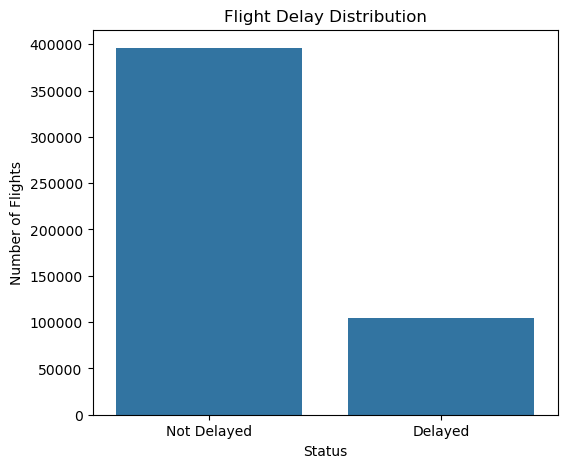

In [219]:
delay_counts = df['delayed'].value_counts()

plt.figure(figsize=(6,5))
sns.barplot(
    x=['Not Delayed', 'Delayed'],
    y=delay_counts.values
)

plt.title('Flight Delay Distribution')
plt.ylabel('Number of Flights')
plt.xlabel('Status')

plt.show()

This figure shows the distribution of data between the delayed and not Delayed fields.<br>
It shows that the not delayed flights around 800K record and the deleayed ones around 200K record.<br>
The dataset is imbalanced but it is also real data because it shows the real flights.

In [222]:
delay_ratio = df['delayed'].mean() * 100

print(f"{delay_ratio:.2f}% of flights are delayed.")

20.82% of flights are delayed.


This shows the ratio of the delayed flights with all data in dataset<br>
It is a normal ratio beacause there is no flight have a 50% to delayed, it is ralated on a multiple factors to be delayed

# Delays by Month

Need to see if there is a relation between the months in the year and the delay flights or not?

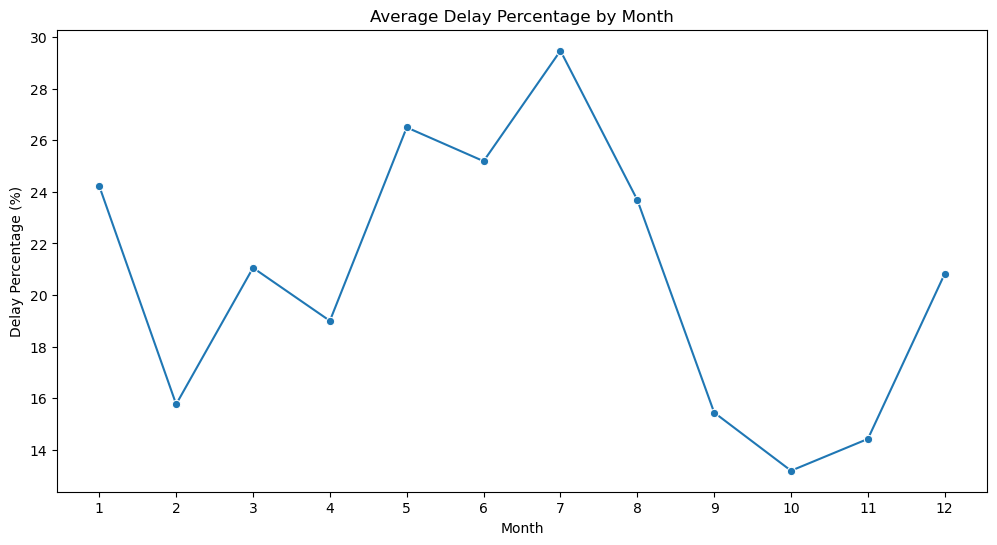

In [227]:
monthly_delay = df.groupby('month')['delayed'].mean() * 100

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_delay.index,
    y=monthly_delay.values,
    marker='o'
)

plt.title('Average Delay Percentage by Month')
plt.xlabel('Month')
plt.ylabel('Delay Percentage (%)')

plt.xticks(range(1,13))

plt.show()

In [229]:
monthly_delay.sort_values(ascending=False)

month
7     29.468599
5     26.495904
6     25.188256
1     24.219290
8     23.684877
3     21.056139
12    20.826740
4     19.000024
2     15.766499
9     15.444806
11    14.424363
10    13.191304
Name: delayed, dtype: float64

<br>
This Shows the average delayed for every month in the year from the figure and ratios <br>
We can see that the summer season has the most delayed because the high congestion in holidays<br>
And the winter months after them because the weather conditions and chrismas holiday


# Delays by Day of week

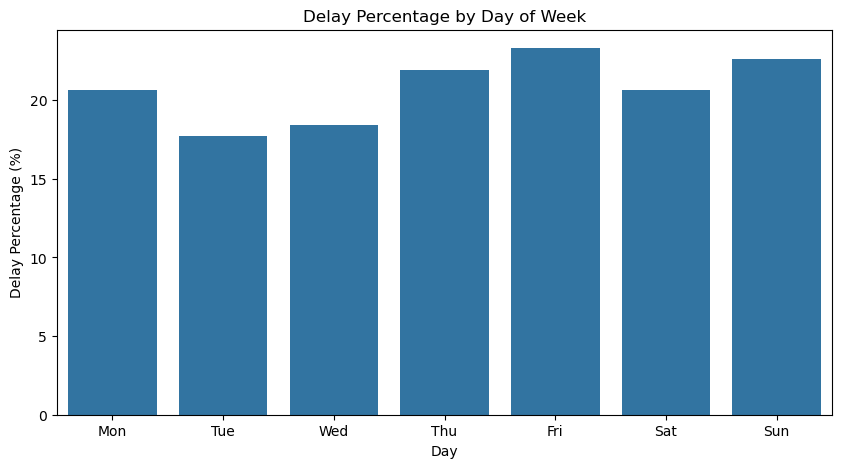

In [233]:
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

weekly_delay = df.groupby('day_of_week')['delayed'].mean() * 100

plt.figure(figsize=(10,5))

sns.barplot(
    x=days,
    y=weekly_delay.values
)

plt.title('Delay Percentage by Day of Week')
plt.xlabel('Day')
plt.ylabel('Delay Percentage (%)')

plt.show()

Here we can see that the Friday and Sunday have a little more delayed<br>
The reason is because that they are the weekends of the week so it make more traffic in the Airports and flights

# Delays by Period of Day

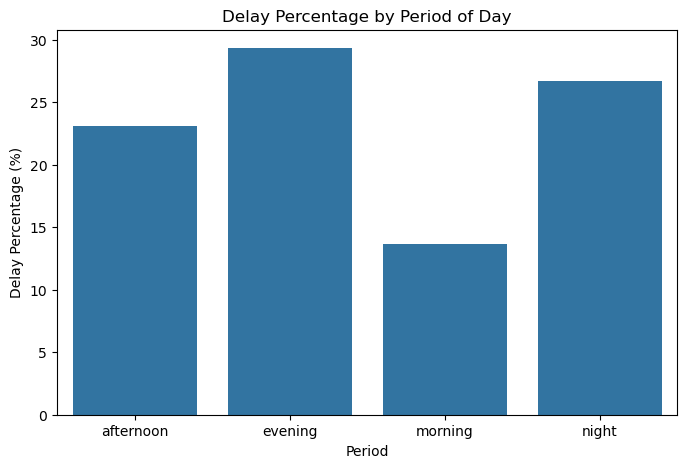

In [237]:
period_delay = df.groupby('period_of_day')['delayed'].mean() * 100

plt.figure(figsize=(8,5))

sns.barplot(
    x=period_delay.index,
    y=period_delay.values
)

plt.title('Delay Percentage by Period of Day')
plt.xlabel('Period')
plt.ylabel('Delay Percentage (%)')

plt.show()

Depends on the figure we can see that the delays usually happend in evening and night <br>
Also means that the flights schedule later in same day are more likely to be delayed comparing it with morning <br>
And in case any one flight delayed in some times it affect many flights after it <br>
And the early time flights if they delayed they affect the flights after that time, for example in case a flight in afternooon is delayed the flights that scheduled in evening and night also delayed

# Distance vs Delay

Need to see if the Distance is a Strong predictor for delays or not?

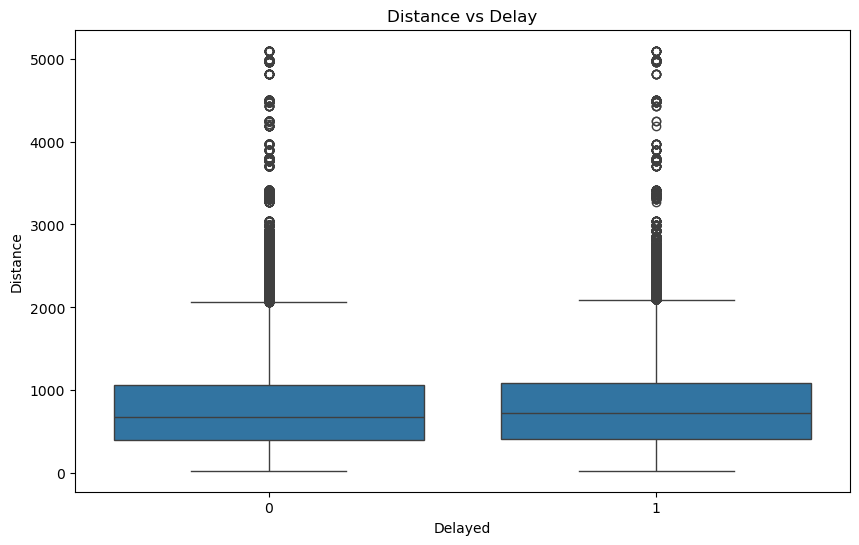

In [242]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='delayed',
    y='distance',
    data=df
)

plt.title('Distance vs Delay')
plt.xlabel('Delayed')
plt.ylabel('Distance')
plt.show()

The Boxplots shows that the distance don't have a big different between the Delayed and not delayed flights. <br>
Both ones have similar median and interquartiles ranges. <br>
The outliers here is the flights that they have a long distnce. <br>
so from what we see the data is similar between the groups that means the distance field is not strong predictor for flight delays.

# Top 10 Airports with highest delay

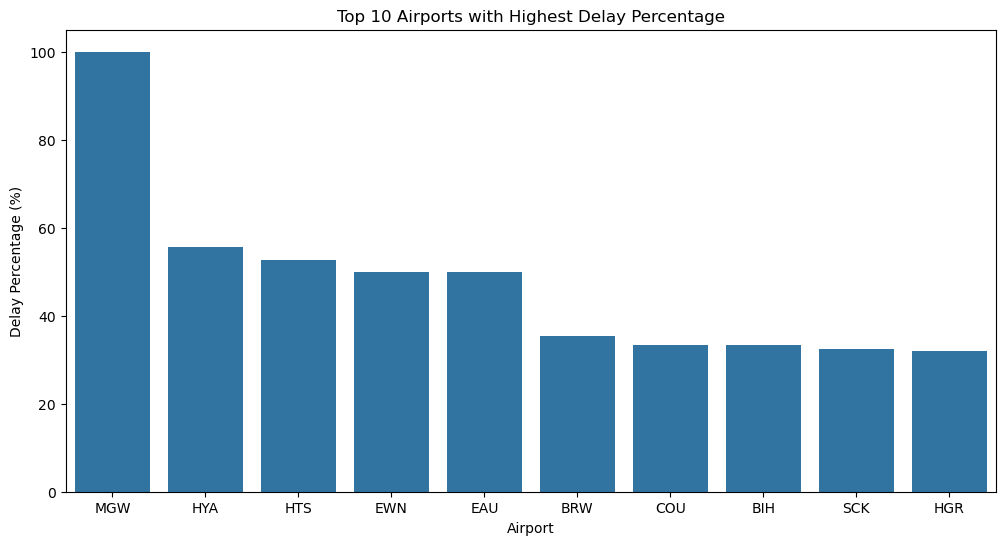

In [245]:
top_airports = (
    df.groupby('origin')['delayed']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    * 100
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_airports.index,
    y=top_airports.values
)

plt.title('Top 10 Airports with Highest Delay Percentage')
plt.xlabel('Airport')
plt.ylabel('Delay Percentage (%)')

plt.show()

As we see some of the Airports have a High ratio in delays, may due to the high traffic volume, weather and place this Airport in and airprt congestion

# Top 10 Airlines with highest delay

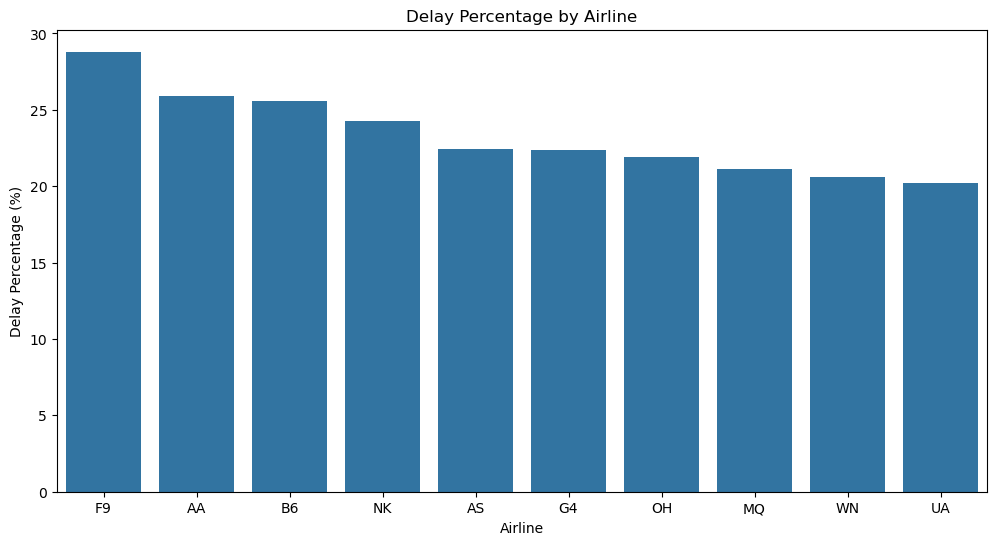

In [250]:
carrier_delay = (
    df.groupby('op_unique_carrier')['delayed']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    * 100
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=carrier_delay.index,
    y=carrier_delay.values
)

plt.title('Delay Percentage by Airline')
plt.xlabel('Airline')
plt.ylabel('Delay Percentage (%)')

plt.show()

Some of the airlines has better schedule than the others thats because the operational efficiency differnt between carriers

# Correlation Heatmap

Need to see the features that can affect the delay column and the features that they don't have a strong effect on it

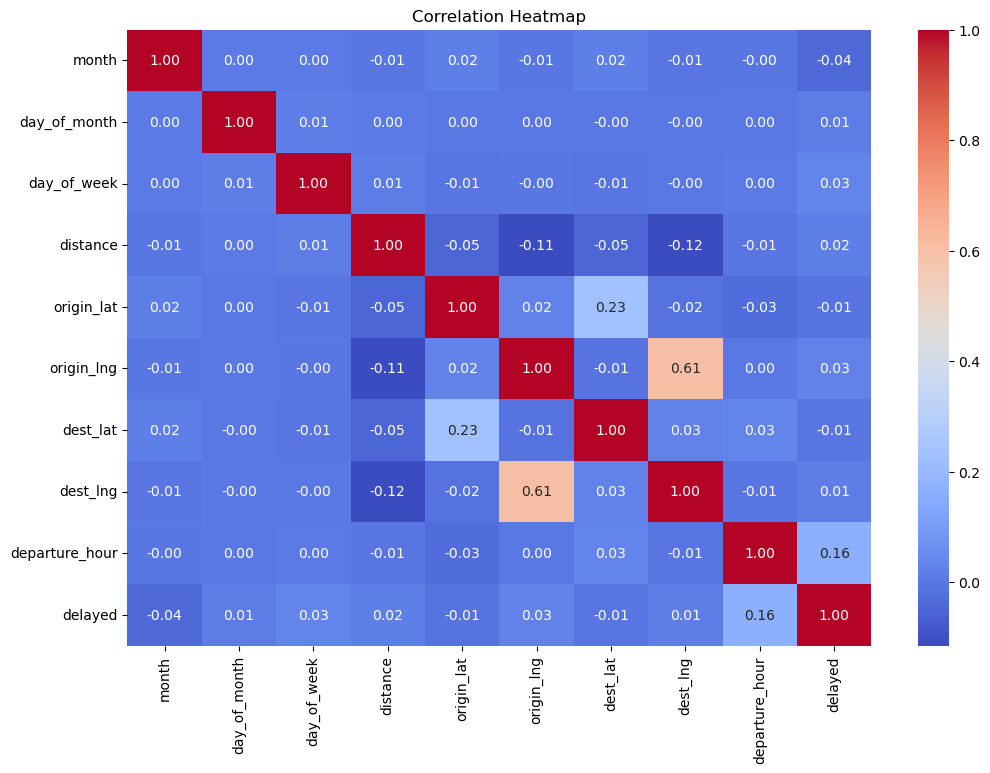

In [255]:
numeric_cols = [
    'month',
    'day_of_month',
    'day_of_week',
    'distance',
    'origin_lat',
    'origin_lng',
    'dest_lat',
    'dest_lng',
    'departure_hour',
    'delayed'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

Depends on the heat map most features have a weak linear correlation with delay field, that means the flight delay are influenced by many factors (features) not only one factor.

The strongest relation is the one between departure hour with delay, but is also weak one because the value is 0.16 <br>
But as what i say before that the time of flight delay in day affect the flights after it so thats whay it is stronger a bit than the others

**To prove what i said we will check the delay perventage throw the day**

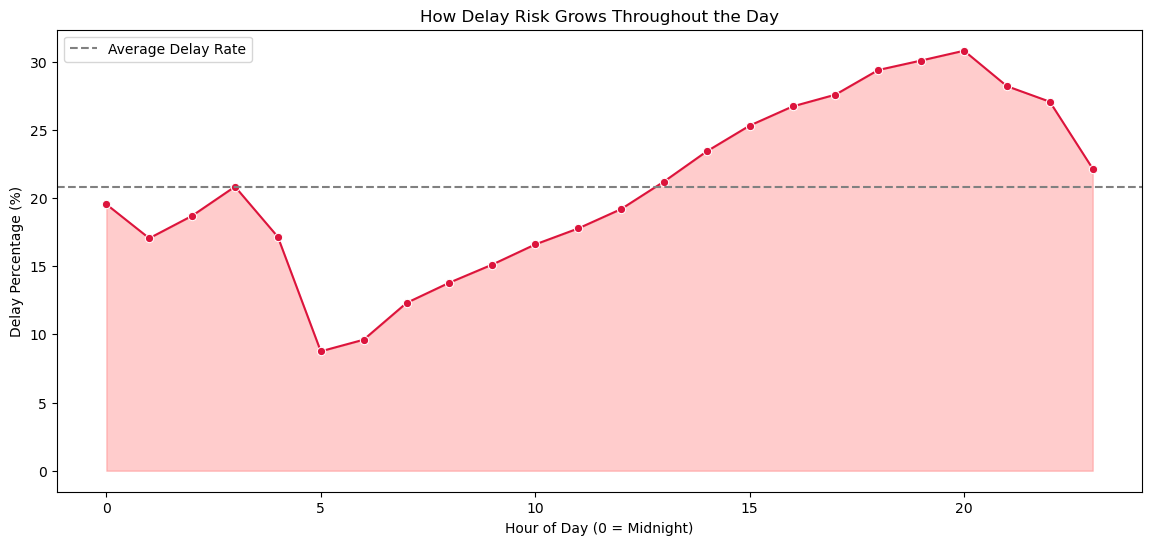

In [260]:
hour_delay = df.groupby('departure_hour')['delayed'].mean() * 100

plt.figure(figsize=(14,6))
sns.lineplot(x=hour_delay.index, y=hour_delay.values, marker='o', color='crimson')
plt.axhline(y=df['delayed'].mean()*100, color='gray', linestyle='--', label='Average Delay Rate')
plt.fill_between(hour_delay.index, hour_delay.values, alpha=0.2, color='red')
plt.title('How Delay Risk Grows Throughout the Day')
plt.xlabel('Hour of Day (0 = Midnight)')
plt.ylabel('Delay Percentage (%)')
plt.legend()
plt.show()

As we see the lowest delay risk is on 5-6 Am and after that the delay risk growth, and when we reach 14 pm the delay exceed the average delay percentage to reach at max the 30% chance to delay

# Delay Heatmap(Month vs Day)

We need to see the if we combine the months with day in the week is they can make a good predictor factor?

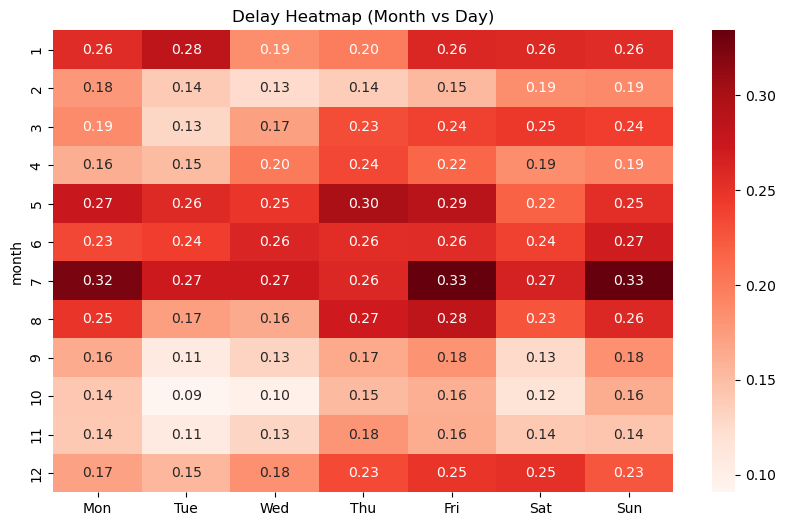

In [265]:
pivot = pd.pivot_table(
    df,
    values='delayed',
    index='month',
    columns='day_of_week',
    aggfunc='mean'
)

# Rename columns from numbers to day names
pivot.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10,6))
sns.heatmap(
    pivot,
    annot=True,
    cmap='Reds',
    fmt='.2f'
)
plt.title('Delay Heatmap (Month vs Day)')
plt.show()

Depends on what we see the highest values is for in (Monday, Friday and Sunday) in July <br>
First why the month is July because it is the peak summer travel season in US, because on school summer vaction and some holidays in US in that month like (Independence day). <br>
**Monday** The travelers return from their weekend trips in monday and the bussiness travelers flight out in monday to start their work week also the delayed of sunday flights carry on monday <br>
**Friday** Start of the weekend so people will travel, and the bussiness travelers fly back to home after work days <br>
**Sunday** The end of the weekend so everyone come back home to start their weekend and most of the return flights be afternoon and evening also the delayed of saturday night carry on the sunday morning <br>